# License Plate Detection
**CSC671 — Deep Learning Project**  
Team: David Lei, Luis Gabriel Ortiz-Anguiano, Ryan Kurian George

## Section 0: Colab Setup & Dataset Download

In [ ]:
import os

# ── Kaggle credentials ────────────────────────────────────────────────────────
# Authentication is handled automatically by the Kaggle CLI.
# Set up credentials using ONE of these methods before running:
#   Option A (recommended): Place kaggle.json in ~/.kaggle/kaggle.json
#     Download it from https://www.kaggle.com/settings -> API -> Create New Token
#   Option B (Colab): Upload kaggle.json and run:
#     from google.colab import files; files.upload()  # upload kaggle.json
#     !mkdir -p ~/.kaggle && mv kaggle.json ~/.kaggle/ && chmod 600 ~/.kaggle/kaggle.json

# ── Dataset ───────────────────────────────────────────────────────────────────
DATASET_SLUG = 'adilshamim8/license-plate-recognition'

!pip install kaggle -q
!kaggle datasets download -d {DATASET_SLUG} --unzip -p data/raw/

print('Dataset downloaded and extracted to data/raw/')

Dataset URL: https://www.kaggle.com/datasets/adilshamim8/license-plate-recognition
License(s): Attribution 4.0 International (CC BY 4.0)
100% 502M/502M [00:20<00:00, 25.2MB/s]

Dataset downloaded and extracted to data/raw/


## Section 1: Data Exploration & Visualization

In [ ]:
import os
import pandas as pd
import cv2
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np

# Paths
DATA_ROOT = os.path.join('data', 'raw')

TRAIN_DIR = os.path.join(DATA_ROOT, 'train', 'train')
VALID_DIR = os.path.join(DATA_ROOT, 'valid', 'valid')
TEST_DIR  = os.path.join(DATA_ROOT, 'test',  'test')

TRAIN_CSV = os.path.join(TRAIN_DIR, '_annotations.csv')
VALID_CSV = os.path.join(VALID_DIR, '_annotations.csv')
TEST_CSV  = os.path.join(TEST_DIR,  '_annotations.csv')

In [ ]:
# Load annotations
train_df = pd.read_csv(TRAIN_CSV)
valid_df = pd.read_csv(VALID_CSV)
test_df  = pd.read_csv(TEST_CSV)

print(f'Train samples : {len(train_df)}')
print(f'Valid samples : {len(valid_df)}')
print(f'Test  samples : {len(test_df)}')
print(f'Total         : {len(train_df) + len(valid_df) + len(test_df)}')
print()
print('Sample rows:')
train_df.head()

Train samples : 7357
Valid samples : 2195
Test  samples : 1085
Total         : 10637

Sample rows:


,filename,width,height,class,xmin,ymin,xmax,ymax
0,xemay1793_jpg.rf.0dc26bab2eb4bb60c25bf0430a744...,472,303,License_Plate,154,82,218,127
1,xemay1850_jpg.rf.a89277812aac9136da653af67d7e3...,472,303,License_Plate,187,122,249,169
2,rotatequandoi50_jpg.rf.fcc6a91af1b79436df370a0...,764,428,License_Plate,260,322,325,370
3,Cars354_png_jpg.rf.52d6d5fb18efb7075b02ccc55c4...,400,267,License_Plate,64,201,101,221
4,CarLongPlateGen2076_jpg.rf.2c1888f949cec4ec6e8...,472,303,License_Plate,316,242,412,271


In [ ]:
# Basic stats on bounding box sizes
train_df['box_width']  = train_df['xmax'] - train_df['xmin']
train_df['box_height'] = train_df['ymax'] - train_df['ymin']

print('Bounding box width  — mean: {:.1f}, min: {}, max: {}'.format(
    train_df['box_width'].mean(), train_df['box_width'].min(), train_df['box_width'].max()))
print('Bounding box height — mean: {:.1f}, min: {}, max: {}'.format(
    train_df['box_height'].mean(), train_df['box_height'].min(), train_df['box_height'].max()))
print()
print('Image width  — mean: {:.1f}, min: {}, max: {}'.format(
    train_df['width'].mean(), train_df['width'].min(), train_df['width'].max()))
print('Image height — mean: {:.1f}, min: {}, max: {}'.format(
    train_df['height'].mean(), train_df['height'].min(), train_df['height'].max()))

Bounding box width  — mean: 123.8, min: 5, max: 3890
Bounding box height — mean: 63.2, min: 3, max: 1946

Image width  — mean: 593.2, min: 90, max: 5312
Image height — mean: 420.1, min: 86, max: 4608


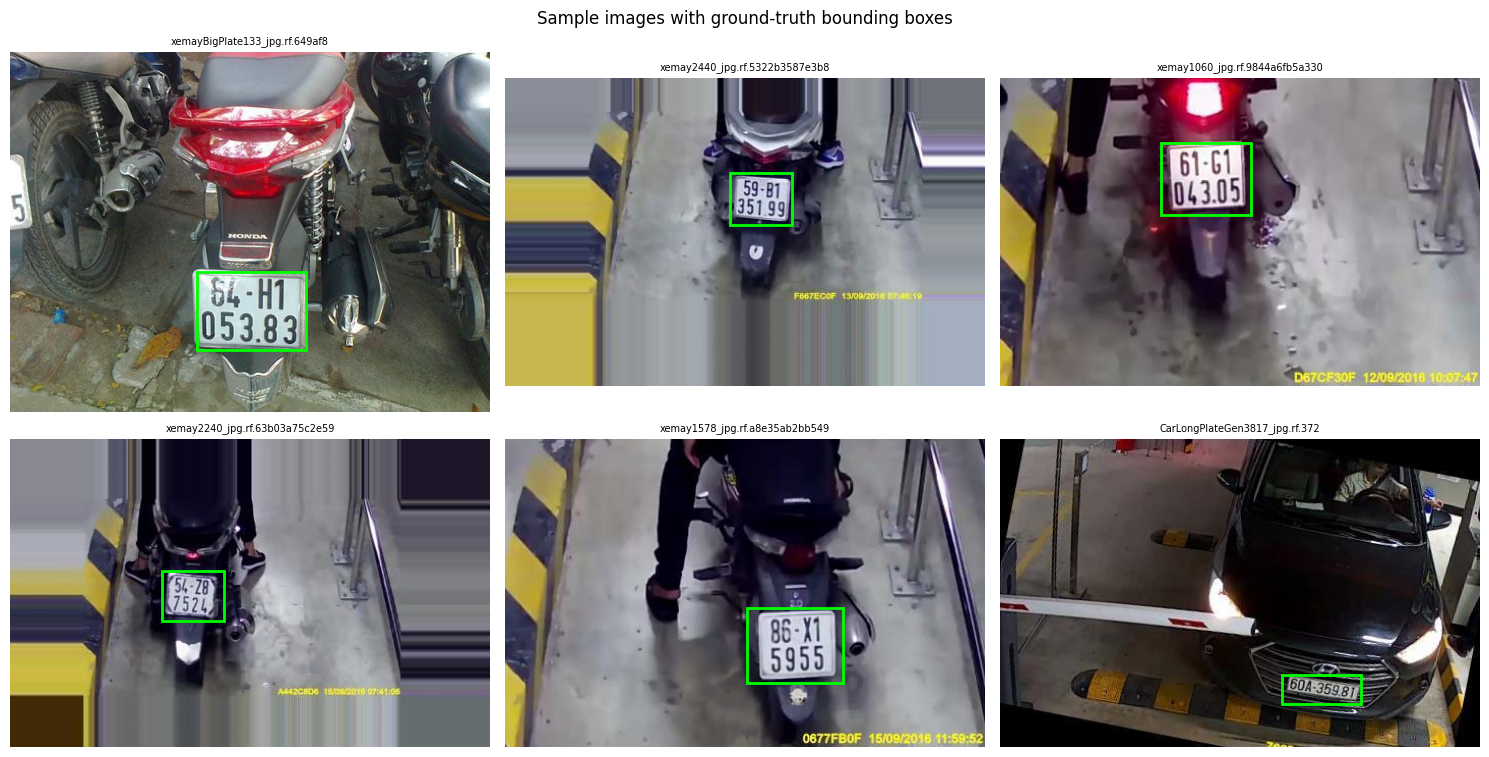

In [ ]:
def show_images_with_boxes(df, img_dir, n=6, cols=3):
    """Display n random images with their ground-truth bounding boxes."""
    samples = df.sample(n, random_state=42)
    rows = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 4 * rows))
    axes = axes.flatten()

    for ax, (_, row) in zip(axes, samples.iterrows()):
        img_path = os.path.join(img_dir, row['filename'])
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        ax.imshow(img)
        rect = patches.Rectangle(
            (row['xmin'], row['ymin']),
            row['xmax'] - row['xmin'],
            row['ymax'] - row['ymin'],
            linewidth=2, edgecolor='lime', facecolor='none'
        )
        ax.add_patch(rect)
        ax.set_title(row['filename'][:30], fontsize=7)
        ax.axis('off')

    for ax in axes[n:]:
        ax.axis('off')

    plt.suptitle('Sample images with ground-truth bounding boxes', fontsize=12)
    plt.tight_layout()
    plt.show()


show_images_with_boxes(train_df, TRAIN_DIR, n=6)

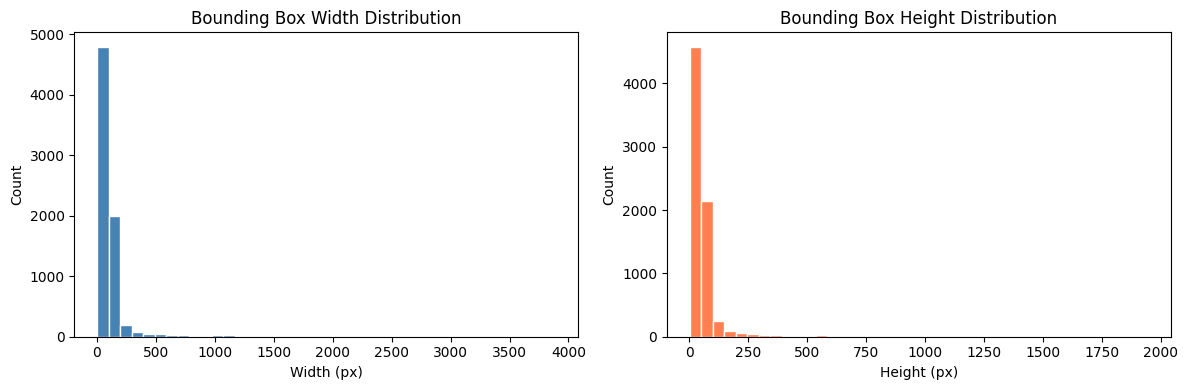

In [ ]:
# Distribution of bounding box sizes
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(train_df['box_width'], bins=40, color='steelblue', edgecolor='white')
axes[0].set_title('Bounding Box Width Distribution')
axes[0].set_xlabel('Width (px)')
axes[0].set_ylabel('Count')

axes[1].hist(train_df['box_height'], bins=40, color='coral', edgecolor='white')
axes[1].set_title('Bounding Box Height Distribution')
axes[1].set_xlabel('Height (px)')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

## Section 2: Dataset & DataLoader

We resize every image to a fixed size (224×224) so the model always receives the same input shape.
The bounding box coordinates are scaled to match the resized image, then normalized to [0, 1]
so the model outputs values in a consistent range regardless of original image size.

In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T

IMG_SIZE = 224  # resize all images to this square size


class LicensePlateDataset(Dataset):
    def __init__(self, csv_path, img_dir, img_size=IMG_SIZE):
        self.df      = pd.read_csv(csv_path)
        self.img_dir = img_dir
        self.img_size = img_size
        self.transform = T.Compose([
            T.ToTensor(),                        # HWC uint8 -> CHW float [0,1]
            T.Normalize(mean=[0.485, 0.456, 0.406],
                        std=[0.229, 0.224, 0.225])  # ImageNet stats
        ])

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        # Load image and resize
        img_path = os.path.join(self.img_dir, row['filename'])
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        orig_w, orig_h = row['width'], row['height']
        img = cv2.resize(img, (self.img_size, self.img_size))

        # Scale bounding box to resized image, then normalize to [0, 1]
        scale_x = self.img_size / orig_w
        scale_y = self.img_size / orig_h

        bbox = torch.tensor([
            (row['xmin'] * scale_x) / self.img_size,
            (row['ymin'] * scale_y) / self.img_size,
            (row['xmax'] * scale_x) / self.img_size,
            (row['ymax'] * scale_y) / self.img_size,
        ], dtype=torch.float32)

        image = self.transform(img)
        return image, bbox

In [ ]:
# Build datasets
train_dataset = LicensePlateDataset(TRAIN_CSV, TRAIN_DIR)
valid_dataset = LicensePlateDataset(VALID_CSV, VALID_DIR)
test_dataset  = LicensePlateDataset(TEST_CSV,  TEST_DIR)

# Build DataLoaders
BATCH_SIZE = 32

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2)
valid_loader = DataLoader(valid_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print(f'Train batches : {len(train_loader)}')
print(f'Valid batches : {len(valid_loader)}')
print(f'Test  batches : {len(test_loader)}')

Train batches : 230
Valid batches : 69
Test  batches : 34


In [ ]:
# Sanity check — load one batch and verify shapes
images, bboxes = next(iter(train_loader))

print(f'Image batch shape : {images.shape}')   # (32, 3, 224, 224)
print(f'BBox  batch shape : {bboxes.shape}')   # (32, 4)
print(f'BBox values (first sample): {bboxes[0]}')

Image batch shape : torch.Size([32, 3, 224, 224])
BBox  batch shape : torch.Size([32, 4])
BBox values (first sample): tensor([0.4153, 0.3498, 0.6250, 0.6073])


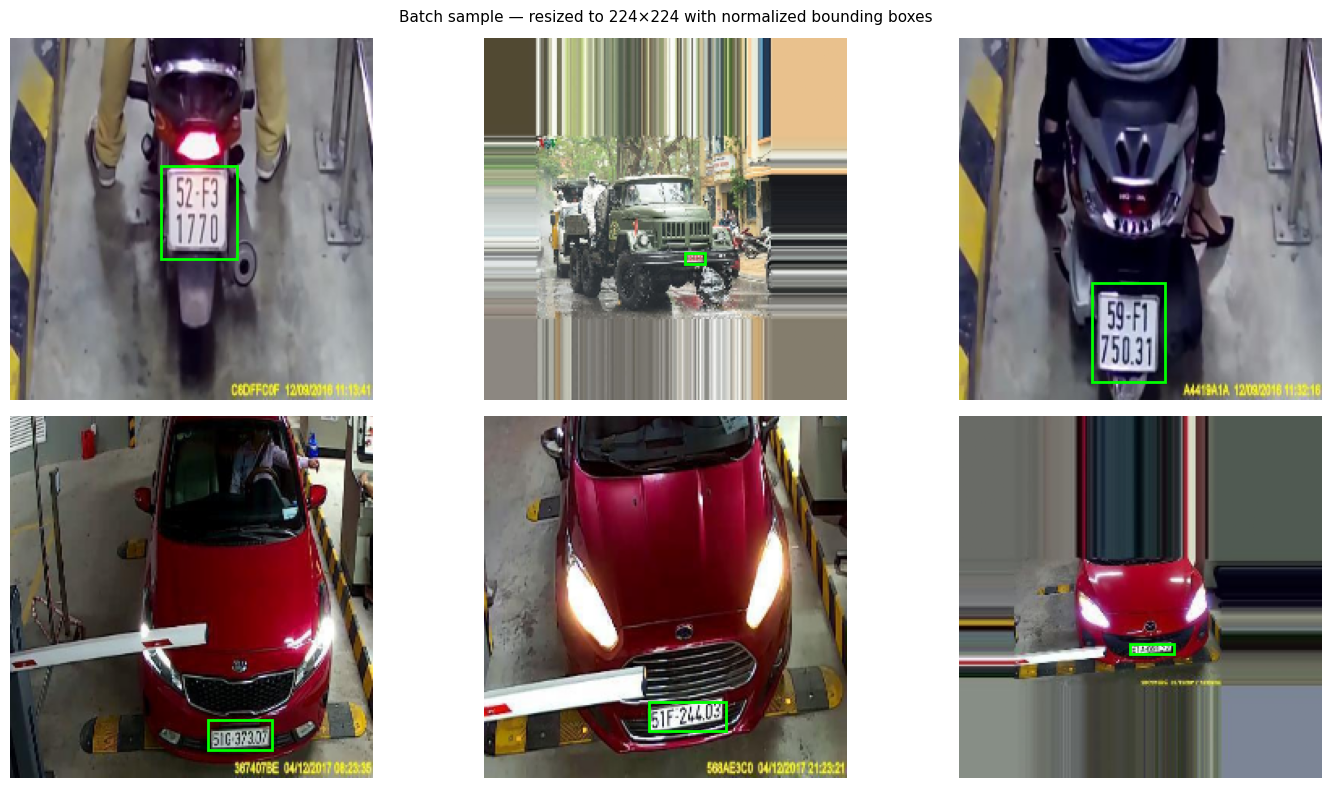

In [ ]:
# Visualize a batch to confirm boxes still look right after resizing
def show_batch(images, bboxes, n=6, cols=3):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

    rows = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 4 * rows))
    axes = axes.flatten()

    for i in range(n):
        img = images[i] * std + mean          # undo normalization
        img = img.permute(1, 2, 0).numpy()    # CHW -> HWC
        img = np.clip(img, 0, 1)

        xmin, ymin, xmax, ymax = bboxes[i].numpy() * IMG_SIZE  # back to pixels

        axes[i].imshow(img)
        rect = patches.Rectangle(
            (xmin, ymin), xmax - xmin, ymax - ymin,
            linewidth=2, edgecolor='lime', facecolor='none'
        )
        axes[i].add_patch(rect)
        axes[i].axis('off')

    for ax in axes[n:]:
        ax.axis('off')

    plt.suptitle('Batch sample — resized to 224×224 with normalized bounding boxes', fontsize=11)
    plt.tight_layout()
    plt.show()


show_batch(images, bboxes, n=6)

## Section 3: Model Definition

We fine-tune a **ResNet-18** backbone pretrained on ImageNet. The classification head is replaced with a small regression head that predicts 4 normalized bounding-box coordinates `[xmin, ymin, xmax, ymax] ∈ [0, 1]`.

In [ ]:
import torchvision.models as models
import torch.nn as nn


class LicensePlateDetector(nn.Module):
    """Pretrained ResNet backbone with a 4-output bounding-box regression head."""

    def __init__(self, backbone='resnet18', pretrained=True):
        super().__init__()
        if backbone == 'resnet18':
            base = models.resnet18(
                weights=models.ResNet18_Weights.DEFAULT if pretrained else None)
            feat_dim = 512
        else:
            base = models.resnet50(
                weights=models.ResNet50_Weights.DEFAULT if pretrained else None)
            feat_dim = 2048

        self.backbone = nn.Sequential(*list(base.children())[:-1])  # drop FC layer
        self.head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(feat_dim, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(256, 4),
            nn.Sigmoid(),  # outputs in [0, 1] matching normalized bbox targets
        )

    def forward(self, x):
        return self.head(self.backbone(x))


def compute_iou(preds, targets):
    """Per-sample IoU. Both tensors are (N, 4) normalized [xmin, ymin, xmax, ymax]."""
    ix1 = torch.max(preds[:, 0], targets[:, 0])
    iy1 = torch.max(preds[:, 1], targets[:, 1])
    ix2 = torch.min(preds[:, 2], targets[:, 2])
    iy2 = torch.min(preds[:, 3], targets[:, 3])

    inter  = (ix2 - ix1).clamp(0) * (iy2 - iy1).clamp(0)
    area_p = (preds[:, 2]   - preds[:, 0]).clamp(0) * (preds[:, 3]   - preds[:, 1]).clamp(0)
    area_t = (targets[:, 2] - targets[:, 0]).clamp(0) * (targets[:, 3] - targets[:, 1]).clamp(0)

    return inter / (area_p + area_t - inter).clamp(min=1e-6)

In [ ]:
# Set device and instantiate model
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

model = LicensePlateDetector(backbone='resnet18', pretrained=True).to(device)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total parameters     : {total_params:,}')
print(f'Trainable parameters : {trainable_params:,}')

# Quick forward pass to verify output shape and value range
with torch.no_grad():
    dummy = torch.randn(4, 3, IMG_SIZE, IMG_SIZE).to(device)
    out   = model(dummy)
print(f'Output shape : {out.shape}')                            # (4, 4)
print(f'Output range : [{out.min():.3f}, {out.max():.3f}]')   # [0, 1]

Using device: cpu
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 142MB/s]


Total parameters     : 11,308,868
Trainable parameters : 11,308,868
Output shape : torch.Size([4, 4])
Output range : [0.384, 0.627]


## Section 4: Training Utilities

**Loss:** Smooth L1 (Huber loss) — less sensitive to outliers than MSE while still penalising large errors.  
**Metric:** Mean IoU — human-interpretable measure of box overlap (0 = no overlap, 1 = perfect match).

In [ ]:
import torch.optim as optim


def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = total_iou = 0.0
    for images, bboxes in loader:
        images, bboxes = images.to(device), bboxes.to(device)
        optimizer.zero_grad()
        preds = model(images)
        loss  = criterion(preds, bboxes)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * len(images)
        total_iou  += compute_iou(preds.detach(), bboxes).sum().item()
    n = len(loader.dataset)
    return total_loss / n, total_iou / n


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = total_iou = 0.0
    for images, bboxes in loader:
        images, bboxes = images.to(device), bboxes.to(device)
        preds = model(images)
        total_loss += criterion(preds, bboxes).item() * len(images)
        total_iou  += compute_iou(preds, bboxes).sum().item()
    n = len(loader.dataset)
    return total_loss / n, total_iou / n

## Section 5 & 6: Load Pre-Trained Checkpoint

Skipping hyperparameter search and full training — loading the saved checkpoint directly.

In [ ]:
# ── Set your config here ────────────────────────────────────────────────────
BACKBONE  = 'resnet18'   # backbone the checkpoint was trained with
LR        = 1e-4         # best lr from the search (for reference only)
EPOCHS    = 30           # epochs the model was trained for (for reference only)

# ── Upload or mount your .pt file, then set the path below ──────────────────
# Colab: use the file browser on the left to upload best_model.pt, then set:
SAVE_PATH = 'best_model.pt'   # update this path if needed

# ── Load model ───────────────────────────────────────────────────────────────
model = LicensePlateDetector(backbone=BACKBONE, pretrained=False).to(device)
model.load_state_dict(torch.load(SAVE_PATH, map_location=device))
model.eval()
print(f'Loaded checkpoint: {SAVE_PATH}')
print(f'Backbone: {BACKBONE}  |  Device: {device}')


## Section 7: Evaluation on Test Set

Load the best saved checkpoint and report final metrics on the held-out test set.

## Section 7: Evaluation on Test Set

Load the best saved checkpoint and report final metrics on the held-out test set.

In [ ]:
# Load best checkpoint
model.load_state_dict(torch.load(SAVE_PATH, map_location=device))

test_loss, test_iou = evaluate(model, test_loader, criterion, device)

print('=' * 45)
print(f'  Test Smooth L1 Loss : {test_loss:.4f}')
print(f'  Test Mean IoU       : {test_iou:.4f}')
print('=' * 45)

## Section 8: Visualize Predictions

**Green** = ground truth bounding box. **Red** = model prediction. IoU score shown per image.

In [ ]:
from matplotlib.lines import Line2D


def visualize_predictions(model, dataset, device, n=6, cols=3, seed=0):
    mean_t = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std_t  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

    model.eval()
    rng     = np.random.default_rng(seed)
    indices = rng.choice(len(dataset), n, replace=False)

    rows_n = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows_n, cols, figsize=(5 * cols, 4 * rows_n))
    axes = axes.flatten()

    with torch.no_grad():
        for i, idx in enumerate(indices):
            img, gt_bbox  = dataset[idx]
            pred_bbox = model(img.unsqueeze(0).to(device)).squeeze(0).cpu()
            iou       = compute_iou(pred_bbox.unsqueeze(0), gt_bbox.unsqueeze(0)).item()

            img_vis = (img * std_t + mean_t).permute(1, 2, 0).numpy().clip(0, 1)
            ax = axes[i]
            ax.imshow(img_vis)

            for bbox, color in [(gt_bbox, 'lime'), (pred_bbox, 'red')]:
                x1, y1, x2, y2 = bbox.numpy() * IMG_SIZE
                ax.add_patch(patches.Rectangle(
                    (x1, y1), x2 - x1, y2 - y1,
                    linewidth=2, edgecolor=color, facecolor='none'))

            ax.set_title(f'IoU = {iou:.3f}', fontsize=9)
            ax.axis('off')

    for ax in axes[n:]:
        ax.axis('off')

    fig.legend(
        handles=[Line2D([0], [0], color='lime', lw=2, label='Ground Truth'),
                 Line2D([0], [0], color='red',  lw=2, label='Prediction')],
        loc='lower center', ncol=2, fontsize=10)

    plt.suptitle('Predictions vs Ground Truth — Test Set', fontsize=12)
    plt.tight_layout(rect=[0, 0.05, 1, 1])
    plt.show()


visualize_predictions(model, test_dataset, device, n=6)

## Section 9: OCR — Reading Plate Text

We use **Tesseract OCR** to read alphanumeric characters from the detected plate region.

**Setup (run once per environment):**
- Colab / Linux: `sudo apt install tesseract-ocr` (handled in the cell below)
- Mac local: `brew install tesseract`
- Windows: download the installer from github.com/UB-Mannheim/tesseract/wiki

> Note: OCR accuracy varies by plate style and image quality. The detector (IoU) is the core deep learning metric; OCR is the practical output layer on top of it.

In [ ]:
import subprocess
subprocess.run(['pip', 'install', 'easyocr', '-q'], check=True)

import easyocr
from PIL import Image as PILImage

ocr_reader = easyocr.Reader(['en'], gpu=torch.cuda.is_available())
print('EasyOCR ready')


In [ ]:
def read_plate_text(crop_bgr):
  if crop_bgr is None or crop_bgr.size == 0:
    return ''
  results = ocr_reader.readtext(
      crop_bgr,
      allowlist='ABCDEFGHIJKLMNOPQRSTUVWXYZ0123456789',
  )
  if not results:
      return ''

  confident = [r for r in results if r[2] > 0.3]
  if not confident:
      return ''

  confident.sort(key=lambda r: min(pt[1] for pt in r[0]))
  return ''.join(''.join(c for c in r[1].upper() if c.isalnum()) for r in confident)

In [ ]:
# Demo: OCR on ground-truth plate crops from the test set
N_DEMO = 8
samples = test_df.sample(N_DEMO, random_state=7).reset_index(drop=True)

cols_n = 4
rows_n = (N_DEMO + cols_n - 1) // cols_n
fig, axes = plt.subplots(rows_n, cols_n, figsize=(4 * cols_n, 3 * rows_n))
axes = axes.flatten()

for i, row in samples.iterrows():
    img_bgr  = cv2.imread(os.path.join(TEST_DIR, row['filename']))
    crop     = img_bgr[row['ymin']:row['ymax'], row['xmin']:row['xmax']]
    text     = read_plate_text(crop)
    crop_rgb = cv2.cvtColor(crop, cv2.COLOR_BGR2RGB)

    axes[i].imshow(crop_rgb)
    axes[i].set_title(f'"{text}"' if text else '(unreadable)', fontsize=9)
    axes[i].axis('off')

for ax in axes[N_DEMO:]:
    ax.axis('off')

plt.suptitle('OCR on Ground-Truth Plate Crops — Test Set', fontsize=12)
plt.tight_layout()
plt.show()

## Section 10: Full End-to-End Pipeline

One function that takes a raw image path and returns the detected bounding box + plate text — this is the complete product.

In [ ]:
transform_pipeline = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])


def detect_and_read(image_path, model, device, pad=0.05):
    """Full pipeline: load image → detect plate → crop → OCR.

    Returns (orig_rgb, (x1, y1, x2, y2), plate_text).
    """
    orig_bgr = cv2.imread(image_path)
    orig_rgb = cv2.cvtColor(orig_bgr, cv2.COLOR_BGR2RGB)
    orig_h, orig_w = orig_bgr.shape[:2]

    # Detect bounding box
    tensor = transform_pipeline(PILImage.fromarray(orig_rgb)).unsqueeze(0).to(device)
    model.eval()
    with torch.no_grad():
        bbox = model(tensor).squeeze(0).cpu().numpy()  # normalized [xmin,ymin,xmax,ymax]

    # Scale to original image size
    x1, y1 = int(bbox[0] * orig_w), int(bbox[1] * orig_h)
    x2, y2 = int(bbox[2] * orig_w), int(bbox[3] * orig_h)

    # Padded crop for OCR
    px, py = int((x2 - x1) * pad), int((y2 - y1) * pad)
    cx1, cy1 = max(0, x1 - px), max(0, y1 - py)
    cx2, cy2 = min(orig_w, x2 + px), min(orig_h, y2 + py)

    plate_crop = orig_bgr[cy1:cy2, cx1:cx2]
    plate_text = read_plate_text(plate_crop)

    return orig_rgb, (x1, y1, x2, y2), plate_text

In [ ]:
# Run the full pipeline on 8 test images
import glob

test_image_paths = sorted(glob.glob(os.path.join(TEST_DIR, '*.jpg')))[:8]

cols_n = 2
rows_n = (len(test_image_paths) + cols_n - 1) // cols_n
fig, axes = plt.subplots(rows_n, cols_n, figsize=(10 * cols_n, 5 * rows_n))
axes = axes.flatten()

for i, path in enumerate(test_image_paths):
    orig_rgb, (x1, y1, x2, y2), text = detect_and_read(path, model, device)

    axes[i].imshow(orig_rgb)
    axes[i].add_patch(patches.Rectangle(
        (x1, y1), x2 - x1, y2 - y1,
        linewidth=3, edgecolor='lime', facecolor='none'))

    label = f'Plate: {text}' if text else 'Plate detected (text unreadable)'
    axes[i].set_title(label, fontsize=11, color='white',
                      bbox=dict(facecolor='black', alpha=0.65, pad=4))
    axes[i].axis('off')

for ax in axes[len(test_image_paths):]:
    ax.axis('off')

plt.suptitle('Full Pipeline — Detect + Read License Plate', fontsize=14)
plt.tight_layout()
plt.show()